In [135]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_moons

# if nvidia gpu available use it --> TODO: add to the model and adjoint method such that it is supported
device = "cuda" if torch.cuda.is_available() else "cpu"

## 1. Generate Toy Datasets

In [136]:
# generate moon dataset
coord_moon, label_moon = make_moons(500, noise=0.025)

# generate circle dataset 
coord_circle, label_circle = make_circles(500, noise=0.025)

# dtype of dataset
print(type(coord_circle))

# dimension of data
print(coord_circle.shape)
print(label_circle.shape)

print(coord_circle[0])

<class 'numpy.ndarray'>
(500, 2)
(500,)
[0.09736022 1.01588146]


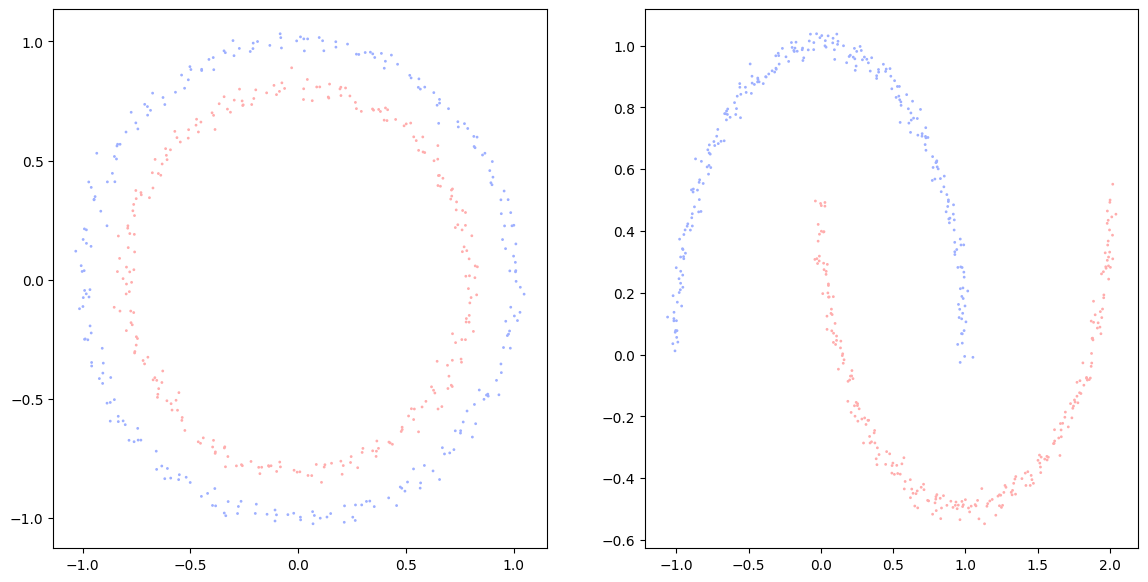

In [137]:
# plot datasets
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# plot circle data
ax[0].scatter(coord_circle[... , 0], coord_circle[... , 1], s=1, c=label_circle, cmap="berlin")

# plot moon data
ax[1].scatter(coord_moon[... , 0], coord_moon[... , 1], s=1, c=label_moon, cmap="berlin")

In [138]:
# Turn circle data into tensor dataset
x_circle = coord_circle[..., 0]
y_circle = coord_circle[..., 1]

circle_numpy = np.array([x_circle, y_circle])
circle_tensor = torch.from_numpy(circle_numpy).float().T
print(circle_tensor.shape)

# Turn moon data into tensor dataset
x_moon = coord_moon[..., 0]
y_moon = coord_moon[..., 1]

moon_numpy = np.array([x_moon, y_moon])
moon_tensor = torch.from_numpy(moon_numpy).float().T
print(moon_tensor.shape)

# Turn Datasets into Dataloader
circle_data = DataLoader(circle_tensor, batch_size=16)
moon_data = DataLoader(moon_tensor, batch_size=16)

torch.Size([500, 2])
torch.Size([500, 2])


## 2. ODE-Solver

### 2.1 Euler Method

In [139]:
# one step of euler method
def euler_step(dynamic, y_n, t_n, step_size):
    step = y_n + step_size * dynamic(y_n, t_n)
    return step

# euler ode solver
def euler_solver(dynamic, y_0, t_0, nb_steps, step_size):
    y_n, t_n = y_0, t_0

    # calculate steps until endstep
    for _ in range(nb_steps):
        y_n = euler_step(dynamic, y_n, t_n, step_size)
        t_n = t_n + step_size
    
    return y_n, t_n

### 2.2 Runge-Kutta method (RK4)

In [140]:
# Runge-Kutta implemenatation (RK4)
def rk4_step(dynamic, y_n, t_n, stepsize):
    # calculate k_n for n in [1, 2, 3, 4] for weighted average of the four increments
    k_1 = dynamic(y_n, t_n)
    k_2 = dynamic(y_n + k_1 * stepsize / 2, t_n + stepsize / 2)
    k_3 = dynamic(y_n + k_2 * stepsize / 2, t_n + stepsize / 2)
    k_4 = dynamic(y_n + stepsize * k_3, t_n + stepsize)

    # calculate step
    step = y_n + stepsize / 6 * (k_1 + 2*k_2 + 2*k_3 + k_4)
    return step

def rk4_solver(model, y_0, t_0, nb_steps, step_size):
    y_n, t_n = y_0, t_0

    # calculate steps until endstep
    for _ in range(nb_steps):
        y_n = rk4_step(model, y_n, t_n, step_size)
        t_n = t_n + step_size
    
    return y_n, t_n

### 2.3 Test ODE Solver

In [141]:
# analytical solution
# dy/dt = -y, y(t) = y_0 * exp(-t)
# dy/dt = 2t, y(t) = y_0 + t^2

def model_exp(y, t):
    """dy/dt = -y"""
    return -y

def model_linear(y, t):
    """dy/dt = 2"""
    return 2

In [142]:
# testing euler 
# case exp decay
y_0_exp = torch.tensor(1.0)
y_end_exp = euler_solver(model_exp, y_0_exp, t_0=0.0, nb_steps=1000, step_size=0.001)
expected_exp = torch.exp(torch.tensor(-1.0))

# case linear function
y_0_linear = torch.tensor(1.0)
y_end_linear = euler_solver(model_linear, y_0_linear, t_0=0.0, nb_steps=1000, step_size=0.001)
expected_linear = y_0_linear + 2

# case 2D input
y_0_2D = torch.ones(8, 2)
y_end_2D = euler_solver(model_exp, y_0_2D, t_0=0.0, nb_steps=10, step_size=0.1)

print(f"exp true: {expected_exp}, solver: {y_end_exp}")
print(f"linear true: {expected_linear}, solver: {y_end_linear}")
print(f"solver 2D: {y_end_2D}")

exp true: 0.3678794503211975, solver: (tensor(0.3677), 1.0000000000000007)
linear true: 3.0, solver: (tensor(3.0000), 1.0000000000000007)
solver 2D: (tensor([[0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487],
        [0.3487, 0.3487]]), 0.9999999999999999)


In [143]:
# testing rk4 
# case exp decay
y_0_exp = torch.tensor(1.0)
y_end_exp = rk4_solver(model_exp, y_0_exp, t_0=0.0, nb_steps=1000, step_size=0.001)
expected_exp = torch.exp(torch.tensor(-1.0))

# case linear function
y_0_linear = torch.tensor(1.0)
y_end_linear = rk4_solver(model_linear, y_0_linear, t_0=0.0, nb_steps=1000, step_size=0.001)
expected_linear = y_0_linear + 2

# case 2D input
y_0_2D = torch.ones(8, 2)
y_end_2D = rk4_solver(model_exp, y_0_2D, t_0=0.0, nb_steps=10, step_size=0.1)

print(f"exp true: {expected_exp}, solver: {y_end_exp}")
print(f"linear true: {expected_linear}, solver: {y_end_linear}")
print(f"solver 2D: {y_end_2D}")

exp true: 0.3678794503211975, solver: (tensor(0.3679), 1.0000000000000007)
linear true: 3.0, solver: (tensor(3.0000), 1.0000000000000007)
solver 2D: (tensor([[0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679],
        [0.3679, 0.3679]]), 0.9999999999999999)


## 3. Adjoint-based Backpropagation 

### 3.1 Custom Autograd Function for Adjoint Method

In [152]:
# custom autograd.Function s.t. pytorch does not calculate computational graph for autograd
class AdjointSolver(torch.autograd.Function):

    # create function to build system of ODEs
    @staticmethod
    def _augmented_dynamics(model, state, t, batch_size, detach_output=True):
        z_0 = state[:, :-1]

        # calculate gradient for trace
        with torch.enable_grad():
            if detach_output:
                z = z_0.detach().requires_grad_(True)
            else:
                z = z_0
            dz_dt = model(z, t)

            grad_trace = torch.zeros(batch_size, device=z.device)
            for i in range(dz_dt.shape[1]):
                grad = torch.autograd.grad(dz_dt[:, i].sum(), z, retain_graph=True, create_graph=not detach_output)[0]
                grad_trace = grad_trace + grad[:, i]
                
            F = torch.cat([dz_dt, -grad_trace.unsqueeze(1)], dim=1)
        
        if detach_output:
            return F.detach()
        else:
            return F 

    # forward pass through the vectorfield-model
    @staticmethod
    def forward(ctx, model, y_0, t_0, t_end, nb_steps, solver, *params):
        # calculate stepsize
        step_size = (t_end - t_0) / nb_steps

        batch_size = y_0.shape[0]

        # define state vector for initial problem with start of function and start of probability
        #log_p_0 = torch.log(distr(y_0))    # removed because for MLE we need backward direction and using this has no meaning. therefore just learning difference in probability is better
        delta_log_p_0 = torch.zeros(batch_size, 1, device=y_0.device)
        s_0 = torch.cat([y_0, delta_log_p_0], dim=1)

        def forward_dynamics(state, t):
            return AdjointSolver._augmented_dynamics(model, state, t, batch_size, detach_output=True)


        # solve initial value problem
        s_end = solver(forward_dynamics, s_0, t_0, nb_steps, step_size)[0]

        # safe variables for backward step
        ctx.model = model
        ctx.save_for_backward(s_end, s_0, y_0)
        ctx.t_0 = t_0
        ctx.t_end = t_end
        ctx.nb_steps = nb_steps
        ctx.solver = solver
        ctx.batch_size = batch_size

        return s_end
    
    # backward pass with adjoint vectorfield to get derivative of loss in respect to param of model
    @staticmethod
    def backward(ctx, dL_ds):
        # import saved variables from forwardpass
        model = ctx.model
        s_end, s_0, y_0, = ctx.saved_tensors
        t_0 = ctx.t_0
        t_end = ctx.t_end
        nb_steps = ctx.nb_steps
        solver = ctx.solver
        batch_size = ctx.batch_size

        # define state vector for initial problem with backwart y dynamic, adjoint dynamic and Loss-grad dynamic
        num_params = sum(p.numel() for p in model.parameters())
        a_end = dL_ds.detach()
        y_end = s_end.detach()
        h_0 = torch.cat([y_end, a_end, torch.zeros(batch_size, num_params, device=y_end.device)], dim=1)

        # calculate lenght of individual dynamics state
        lenght_a = a_end.shape[1]
        lenght_y = y_end.shape[1]

        def cat_dynamics(state, t):
            # define the states
            z_0 = state[:, :lenght_y]
            a_0 = state[:, lenght_y:lenght_y + lenght_a]

            # calculate gradients
            with torch.enable_grad():
                z = z_0.detach().requires_grad_(True)
                dz_dt = AdjointSolver._augmented_dynamics(model, z, t, batch_size, detach_output=False)

                # calculate the ODEs
                da_dt = -torch.autograd.grad(dz_dt, z, grad_outputs=a_0, retain_graph=True)[0]
                grad_params = torch.autograd.grad(dz_dt, model.parameters(), grad_outputs=a_0, retain_graph=True, allow_unused=True)
                # Result tuple of tensors in param shape --> flatten and concat
                flat_parts = []
                for p, g in zip(model.parameters(), grad_params):
                    if g is None:
                        flat_parts.append(torch.zeros(p.numel(), device=z.device))
                    else:
                        flat_parts.append(g.contiguous().flatten())
                dL_dparam = -torch.cat(flat_parts)

                # Broadcast to (batch_size, num_params) so shapes match the augmented state
                dL_dparam_batched = dL_dparam.unsqueeze(0).expand(batch_size, -1)
            
            return torch.cat([dz_dt.detach(), da_dt.detach(), dL_dparam_batched.detach()], dim=1)
        
        # calculate stepsize
        step_size = (t_0 - t_end) / nb_steps

        # solve initial value problem of cat augmented
        h_end = solver(cat_dynamics, h_0, t_end, nb_steps, step_size)[0]

        dy0_dt_full = h_end[:, :lenght_y]
        dy0_dt = dy0_dt_full[:, :-1]
        dL_dparam = h_end[0, lenght_y + lenght_a:]

        # safe gradients of Loss
        idx = 0
        for param in model.parameters():
            # reshape into param shape
            n = param.numel()
            dif = dL_dparam[idx:idx+n].reshape(param.shape)

            # update gradients
            if param.grad is None:
                param.grad = dif.clone()
            else:
                param.grad += dif
            idx+=n
        
        # check if all params have grad now
        assert (idx == len(dL_dparam))

        num_params = sum(1 for _ in model.parameters())

        # return all gradients of forward inputs
        return (None, dy0_dt, None, None, None, None) + (None,) * num_params

### 3.2 Test Parts of Custom Autograd Function

In [145]:
# test function
W = torch.tensor([[1.0, 2.0], [3.0, 4.0]], requires_grad=True)
x = torch.randn(2, 1, requires_grad=True)
a_0 = torch.tensor([[1.0],[2.0]])

print(W.shape, x.shape)

def f(z, t):
    return W**2 @ z

torch.Size([2, 2]) torch.Size([2, 1])


In [146]:
# test forward dynamics
def cat_dynamics(state, t):
    z_0 = state #removed slicing because for testing not needed

    # calculate gradient for trace
    with torch.enable_grad():
        z = z_0.requires_grad_(True)
        dz_dt = f(z, t)

        grad_trace = 0
        for i in range(len(dz_dt)):
            grad_trace += torch.autograd.grad(dz_dt[i], z, retain_graph=True)[0][i]
                
    return torch.cat([dz_dt.detach(), -grad_trace.unsqueeze(0)])

# calculate trace of jacobian
trace_grad_f = cat_dynamics(x, 0)[-1]

print("== trace ==")
print(f"-tr(W): {(-W**2).trace()}")
print(f"cat_dynamic: {trace_grad_f}")

== trace ==
-tr(W): -17.0
cat_dynamic: tensor([-17.])


In [147]:
# test shapes
x = torch.randn(2, 1)
y = torch.rand(1, 2)

print(x)
print(y)

tensor([[ 1.1542],
        [-0.3658]])
tensor([[0.5813, 0.8946]])


In [148]:
# test backward dynamic

def cat_dynamics(state, t):
    # define the states
    z_0 = state # removed slicing because for testing not needed

    # calculate gradients
    with torch.enable_grad():
        z = z_0.detach().requires_grad_(True)
        dz_dt = f(z, t)

        # calculate the ODEs
        da_dt = -torch.autograd.grad(dz_dt, z, grad_outputs=a_0, retain_graph=True)[0]
        dL_dparam = torch.autograd.grad(dz_dt, [W], grad_outputs=a_0, retain_graph=True)
        dL_dparam = -torch.cat([g.flatten() for g in dL_dparam])
            
    return torch.cat([-dz_dt.detach().flatten(), da_dt.detach().flatten(), dL_dparam.detach().flatten()])

gradients = cat_dynamics(x, 0)
dz_adj  = gradients[:2]        # -dz/dt
da_adj  = gradients[2:4]       # da/dt
dW_adj  = gradients[4:]        # dL/dW flat

# calculate refrence directly with pytorch
z_ref = x.detach().requires_grad_(True)
W_ref = W.detach().requires_grad_(True)

dz_dt_ref = W_ref**2 @ z_ref   # shape [2,1]

loss = (a_0 * dz_dt_ref).sum()
loss.backward()

dz_ref = z_ref.grad.flatten()   # dL/dz
dW_ref = W_ref.grad.flatten()   # dL/dW

print("=== da/dt ===")
print(f"cat_dynamic:  {da_adj}")
print(f"Autograd: {-dz_ref}")
print(f"error: {(da_adj - (-dz_ref)).abs().max():.6f}")
print()

print("=== dL/dW ===")
print(f"cat_dynamic:  {dW_adj}")
print(f"Autograd: {-dW_ref}")
print(f"error: {(dW_adj - (-dW_ref)).abs().max():.6f}")

=== da/dt ===
cat_dynamic:  tensor([-19., -36.])
Autograd: tensor([-19., -36.])
error: 0.000000

=== dL/dW ===
cat_dynamic:  tensor([ -2.3084,   1.4631, -13.8502,   5.8524])
Autograd: tensor([ -2.3084,   1.4631, -13.8502,   5.8524])
error: 0.000000


## 4. Model Initialization

In [149]:
# make vector field model
class MLPVectorField(nn.Module):
    def __init__(self, dim, hidden):
        super().__init__()
        # define 1 hidden layer MLP for vector field
        self.net = nn.Sequential(
            nn.Linear(dim+1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, dim)
        )

    def forward(self, y, t):
        t_vec = torch.full((y.shape[0], 1), t)
        inp = torch.cat([y, t_vec], dim=1)
        return self.net(inp)
    

# define the neural ODE class
class NeuralODE(nn.Module):
    def __init__(self, resolution, dim=2, hidden=16):
        super().__init__()
        # MLP to learn vector field
        self.net = MLPVectorField(dim, hidden)
        # safe how many steps should be made to solve ODE
        self.resolution = resolution

    def forward(self, y_0, t_0, t_end, solver):
        adjoint_forward = AdjointSolver.apply
        params = tuple(self.net.parameters())
        # calculate
        output = adjoint_forward(self.net, y_0, t_0, t_end, self.resolution, solver, *params)
        y_end = output[:, :-1]
        y_prob = output[:, -1:]
        
        return y_end, y_prob


## 5. Model Training

In [ ]:
# train step function for Neural ODEs
def make_train_step(model, optimizer, ode_solver, dim_data):
    # define prior
    prior = torch.distributions.MultivariateNormal(torch.zeros(dim_data), torch.eye(dim_data))

    # training function that gets created
    def train_step(y_end, t_0, t_end):
        optimizer.zero_grad()
        model.train()

        # calculate ODE Backward to use MLE on Gauss distr with connection to datapoints
        y_0, delta_prob = model(y_end, t_end, t_0, ode_solver)

        # calculate loss (MLE)
        y_0_prob = prior.log_prob(y_0)
        log_p = y_0_prob + delta_prob
        loss = -log_p.mean()

        # calculate gradient
        loss.backward()
        optimizer.step()

        return loss.item()
    
    return train_step

# training parameters
epochs = 10
lr = 1e-3
t_start = 0
t_end = 1

# init model
model = NeuralODE(100, 2, 16)
#print(model.state_dict())

# define an optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)

# create training function
training_step = make_train_step(model, optimizer, euler_solver, dim_data=2)

train_history = []
eval_history = []
for e in range(epochs):
    print(f"\nEpoch: {e+1}")

    batch_loss = []
    for i, point_batch in enumerate(moon_data, 1):
        print(f"Batch: {i}")
        point_batch = point_batch.to(device)

        # perform a train step
        loss_b = training_step(point_batch, t_start, t_end)
        batch_loss.append(loss_b)
    
    loss_e = np.array(batch_loss).mean()
    train_history.append(loss_e)
    print(f"Loss: {loss_e}")


Epoch: 1


TypeError: 'DataLoader' object cannot be interpreted as an integer

## 6. Model Evaluation/ Visualization